In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Housing.csv")

print(f"Shape   : {df.shape}")
print(f"Target  : price  |  Range: {df['price'].min():,.0f} – {df['price'].max():,.0f}")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print("\nNull counts:\n", nulls if not nulls.empty else "  None")
print("\nNumerical summary:")
print(df.describe().T[["mean", "std", "min", "max"]].round(2))

Shape   : (545, 13)
Target  : price  |  Range: 1,750,000 – 13,300,000

Null counts:
   None

Numerical summary:
                 mean         std        min         max
price      4766729.25  1870439.62  1750000.0  13300000.0
area          5150.54     2170.14     1650.0     16200.0
bedrooms         2.97        0.74        1.0         6.0
bathrooms        1.29        0.50        1.0         4.0
stories          1.81        0.87        1.0         4.0
parking          0.69        0.86        0.0         3.0


In [3]:
# FEATURE ENGINEERING
binary_cols = ["mainroad", "guestroom", "basement",
               "hotwaterheating", "airconditioning", "prefarea"]

df[binary_cols] = df[binary_cols].apply(lambda c: (c.str.lower() == "yes").astype(int))
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=False)
df.columns = [c.replace("furnishingstatus_", "furn_") for c in df.columns]

In [4]:
#  TRAIN / TEST SPLIT
TARGET   = "price"
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape[0]} rows | Test : {X_test.shape[0]} rows")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Train : 436 rows | Test : 109 rows
Features (14): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furn_furnished', 'furn_semi-furnished', 'furn_unfurnished']


In [5]:
#MODEL TRAINING
model = LinearRegression()
model.fit(X_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
#EVALUATION
y_pred = model.predict(X_test_s)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"  RMSE : {rmse:>14,.0f}")
print(f"  R²   : {r2:>14.4f}")
print(f"  MAPE : {mape:>13.2f}%")

  RMSE :      1,324,507
  R²   :         0.6529
  MAPE :         21.04%


In [7]:
## 6. COEFFICIENT INTERPRETATION
coef_df = (
    pd.DataFrame({"feature": FEATURES, "coefficient": model.coef_})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

print("\nCoefficients (standardised — sorted by impact):")
print(coef_df.to_string(index=False))



Coefficients (standardised — sorted by impact):
            feature    coefficient
          bathrooms  521879.027748
               area  519552.416340
    airconditioning  365157.393851
            stories  349251.438906
           prefarea  266656.351993
            parking  192005.953667
           basement  187067.803214
    hotwaterheating  149862.702991
           mainroad  128498.628215
   furn_unfurnished -106204.104713
          guestroom   88768.667686
     furn_furnished   80529.382918
           bedrooms   57349.559419
furn_semi-furnished   28712.175946


Text(0.5, 1.0, 'Residual Plot  |  RMSE = 1.32M')

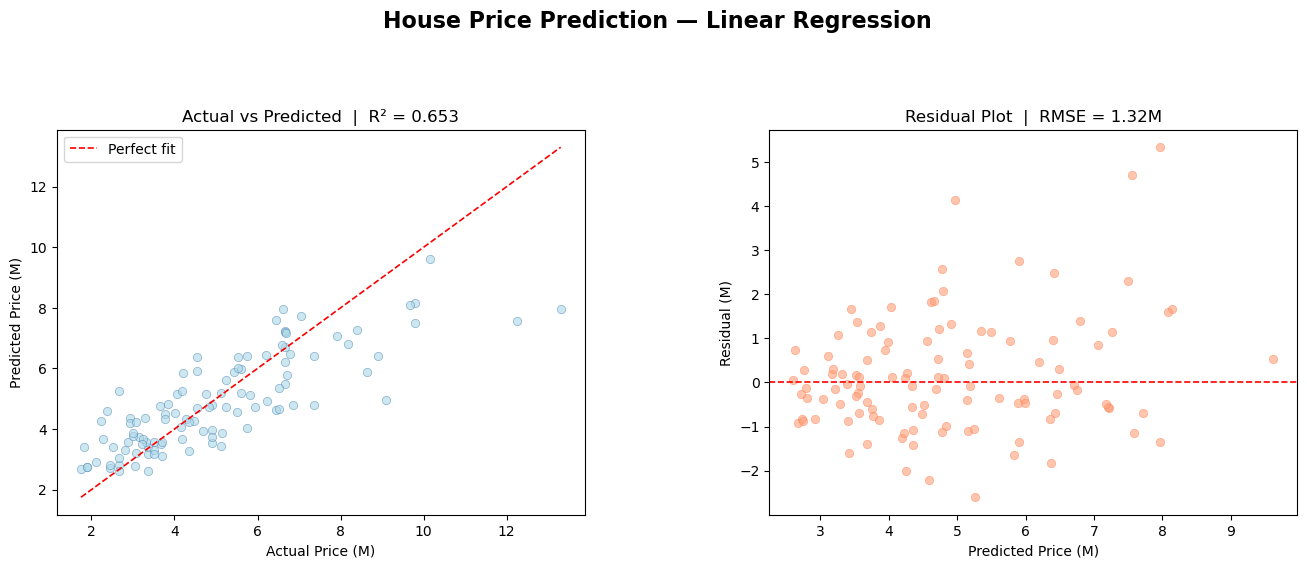

In [8]:
#VISUALISATIONS
fig = plt.figure(figsize=(16, 12))
fig.suptitle("House Price Prediction — Linear Regression", fontsize=16, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- 7a: Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.6, edgecolors="steelblue",
            facecolors="lightblue", linewidths=0.5)
lims = [min(y_test.min(), y_pred.min()) / 1e6, max(y_test.max(), y_pred.max()) / 1e6]
ax1.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
ax1.set_xlabel("Actual Price (M)")
ax1.set_ylabel("Predicted Price (M)")
ax1.set_title(f"Actual vs Predicted  |  R² = {r2:.3f}")
ax1.legend()

# --- 7b: Residuals
residuals = y_test - y_pred
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred / 1e6, residuals / 1e6, alpha=0.6, edgecolors="coral",
            facecolors="lightsalmon", linewidths=0.5)
ax2.axhline(0, color="red", linewidth=1.2, linestyle="--")
ax2.set_xlabel("Predicted Price (M)")
ax2.set_ylabel("Residual (M)")
ax2.set_title(f"Residual Plot  |  RMSE = {rmse/1e6:.2f}M")

In [9]:

# Top-10 Feature Coefficients
ax3 = fig.add_subplot(gs[1, 0])
top10 = coef_df.head(10)
colors = ["steelblue" if v >= 0 else "tomato" for v in top10["coefficient"]]
bars = ax3.barh(top10["feature"][::-1], top10["coefficient"][::-1] / 1e5, color=colors[::-1])
ax3.set_xlabel("Coefficient (×10⁵)")
ax3.set_title("Top-10 Feature Impact")
ax3.axvline(0, color="black", linewidth=0.8)

# --- 7d: Price Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df["price"] / 1e6, bins=30, color="mediumpurple", edgecolor="white", alpha=0.85)
ax4.axvline(df["price"].mean() / 1e6, color="red", linestyle="--", linewidth=1.5,
            label=f"Mean: {df['price'].mean()/1e6:.2f}M")
ax4.set_xlabel("Price (M)")
ax4.set_ylabel("Count")
ax4.set_title("Price Distribution")
ax4.legend()

plt.savefig("house_price_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Plot saved → house_price_results.png")

<Figure size 640x480 with 0 Axes>


✓ Plot saved → house_price_results.png


In [10]:
#SAVE MODEL
joblib.dump({"model": model, "scaler": scaler, "features": FEATURES}, "house_price_model.pkl")
print("✓ Model saved → house_price_model.pkl")


✓ Model saved → house_price_model.pkl


In [11]:
print("EXAMPLE PREDICTIONS")


examples = pd.DataFrame([
    {
        "area": 7420, "bedrooms": 4, "bathrooms": 2, "stories": 3,
        "mainroad": 1, "guestroom": 0, "basement": 0, "hotwaterheating": 0,
        "airconditioning": 1, "parking": 2, "prefarea": 1,
        "furn_furnished": 1, "furn_semi-furnished": 0, "furn_unfurnished": 0,
    },
    {
        "area": 3500, "bedrooms": 2, "bathrooms": 1, "stories": 1,
        "mainroad": 0, "guestroom": 0, "basement": 0, "hotwaterheating": 0,
        "airconditioning": 0, "parking": 0, "prefarea": 0,
        "furn_furnished": 0, "furn_semi-furnished": 0, "furn_unfurnished": 1,
    },
    {
        "area": 9960, "bedrooms": 5, "bathrooms": 3, "stories": 4,
        "mainroad": 1, "guestroom": 1, "basement": 1, "hotwaterheating": 1,
        "airconditioning": 1, "parking": 3, "prefarea": 1,
        "furn_furnished": 1, "furn_semi-furnished": 0, "furn_unfurnished": 0,
    },
])

examples_s = scaler.transform(examples[FEATURES])
preds      = model.predict(examples_s)

labels = ["Mid-range 4BR", "Budget 2BR", "Premium 5BR"]
for lbl, pred in zip(labels, preds):
    print(f"  {lbl:20s} → ₹ {pred:>12,.0f}")

print("\n✓ Done.")


EXAMPLE PREDICTIONS
  Mid-range 4BR        → ₹    7,968,276
  Budget 2BR           → ₹    2,327,757
  Premium 5BR          → ₹   11,677,690

✓ Done.


In [12]:
print("EXAMPLE PREDICTIONS")


examples = pd.DataFrame([
    {
        "area": 7420, "bedrooms": 4, "bathrooms": 2, "stories": 3,
        "mainroad": 1, "guestroom": 0, "basement": 0, "hotwaterheating": 0,
        "airconditioning": 1, "parking": 2, "prefarea": 1,
        "furn_furnished": 1, "furn_semi-furnished": 0, "furn_unfurnished": 0,
    },
    {
        "area": 3500, "bedrooms": 2, "bathrooms": 1, "stories": 1,
        "mainroad": 0, "guestroom": 0, "basement": 0, "hotwaterheating": 0,
        "airconditioning": 0, "parking": 0, "prefarea": 0,
        "furn_furnished": 0, "furn_semi-furnished": 0, "furn_unfurnished": 1,
    },
    {
        "area": 9960, "bedrooms": 5, "bathrooms": 3, "stories": 4,
        "mainroad": 1, "guestroom": 1, "basement": 1, "hotwaterheating": 1,
        "airconditioning": 1, "parking": 3, "prefarea": 1,
        "furn_furnished": 1, "furn_semi-furnished": 0, "furn_unfurnished": 0,
    },
])

examples_s = scaler.transform(examples[FEATURES])
preds      = model.predict(examples_s)

labels = ["Mid-range 4BR", "Budget 2BR", "Premium 5BR"]
for lbl, pred in zip(labels, preds):
    print(f"  {lbl:20s} → ₹ {pred:>12,.0f}")

print("\n✓ Done.")


EXAMPLE PREDICTIONS
  Mid-range 4BR        → ₹    7,968,276
  Budget 2BR           → ₹    2,327,757
  Premium 5BR          → ₹   11,677,690

✓ Done.
